In [ ]:
import papermill as pm
from jaxcmr.helpers import find_project_root
from IPython.display import Image, display
import os

# Model Fitting
Find the best fitting parameters for a model under specified constraints, simulate the model from the fitted parameters and specified trial scheme, and generate benchmark diagnostics. 

In [ ]:
base_params = {
    # Flow toggles
    "redo_fits": False,
    "redo_sims": False,
    "redo_figures": False,
    "handle_elis": False,
    "filter_repeated_recalls": True,
    # Run configuration
    "base_run_tag": "cat_spc_mse_fixed_term",
    "experiment_count": 200,
    "max_subjects": 0,
    # Data parameters
    "base_data_tag": "TalmiEEG",
    "data_tag": "TalmiEEG",
    "data_path": "data/TalmiEEG.h5",
    "trial_query": "data['subject'] > -1",
    "target_directory": "projects/TalmiEEG/results/",
    # algorithm selection
    "component_paths": {
        "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
        "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
        "context_create_fn": "jaxcmr.components.context.init",
        "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
    },
    "sim_alg_path": "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop",
    "loss_fn_path": "jaxcmr.loss.cat_spc_mse.MemorySearchCatSpcMseFnGenerator",
    "fit_alg_path": "jaxcmr.fitting.ScipyDE",
    # hyperparameters
    "seed": 0,
    "relative_tolerance": 0.001,
    "popsize": 15,
    "num_steps": 1000,
    "cross_rate": 0.9,
    "diff_w": 0.85,
    "best_of": 3,
    # analysis configuration
    "comparison_analysis_configs": [
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc_negative",
            "kwargs": {"category_field": "condition", "category_values": [1]},
            "ylim": [.2, .8],
        },
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc_neutral",
            "kwargs": {"category_field": "condition", "category_values": [2]},
            "ylim": [.2, .8],
        },
        {"target": "jaxcmr.analyses.spc.plot_spc", "figure_suffix": "spc"},
        {"target": "jaxcmr.analyses.crp.plot_crp", "figure_suffix": "crp"},
        {"target": "jaxcmr.analyses.pnr.plot_pnr", "figure_suffix": "pnr"},
        # {
        #     "target": "jaxcmr.analyses.termination_probability.plot_termination_probability", "figure_suffix": "termination_probability"
        # },
    ],
    "single_analysis_configs": [
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc",
            "kwargs": {
                "category_field": "condition",
                "category_values": [1, 2],
                "labels": ["Negative", "Neutral"],
            },
            "ylim": [.2, .8],
            "color_cycle": ["red", "black"]
        },
        {
            "target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall",
            "figure_suffix": "cat_lpp_by_recall_NEGATIVE_EARLYLPP",
            "kwargs": {
                "category_field": "condition",
                "labels": ["Recalled", "Unrecalled"],
                "category_value": 1,
                "contrast_name": "Negative",
                "lpp_field": "EarlyLPP",
            },
            "ylim": [-0.6, 2.2],
        },
            {
            "target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall",
            "figure_suffix": "cat_lpp_by_recall_NEUTRAL_EARLYLPP",
            "kwargs": {
                "category_field": "condition",
                "labels": ["Recalled", "Unrecalled"],
                "category_value": 2,
                "contrast_name": "Neutral",
                "lpp_field": "EarlyLPP",
            },
            "ylim": [-0.6, 2.2],
        }
    ],
}

In [ ]:
varied_parameters = [
    # # Pure-Attention SimpleECMR model, Additive Interaction varying emotion_scale
    # {
    #     "model_name": "AttentionSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.simple_attention_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #         },
    #     },
    # },
    #     {
    #     "model_name": "MultiplicativeAttentionSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.simple_attention_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": True,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #         },
    #     },
    # },
    #         {
    #     "model_name": "AdditiveIsolatedArousalSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.simple_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #         },
    #     },
    # },
    #             {
    #     "model_name": "MultiplicativeIsolatedArousalSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.simple_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": True,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #         },
    #     },
    # },
    #                 {
    #     "model_name": "SumInteractionSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.simple_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": True,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #         },
    #     },
    # },
    #     {
    #     "model_name": "EEGAttentionSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.eeg_simple_attention_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #             "lpp_scale": [2.220446049250313e-16, 19.9999999999999998],
    #         },
    #     },
    # },
    #         {
    #     "model_name": "EEGTwoLayerSimpleECMRNoStop",
    #     "make_factory_path": "jaxcmr.models.eeg_simple_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #             "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
    #             "lpp_scale": [2.220446049250313e-16, 19.9999999999999998],
    #         },
    #     },
    # },
    #         {
    #     "model_name": "WeirdCMRNoStop",
    #     "make_factory_path": "jaxcmr.models.cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "item_support": [2.220446049250313e-16, 99.9999999999999998],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
    #             "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
    #             "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    #         },
    #     },
    # },
            {
        "model_name": "2EEGAttentionECMRNoStop",
        "make_factory_path": "jaxcmr.models.eeg_simple_attention_ecmr.make_factory",
        "parameters": {
            "fixed": {
                "allow_repeated_recalls": False,
                "learn_after_context_update": False,
                "modulate_emotion_by_primacy": False,
            },
            "free": {
                "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "shared_support": [2.220446049250313e-16, 99.9999999999999998],
                "item_support": [2.220446049250313e-16, 99.9999999999999998],
                "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
                "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
                "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
                "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
                "lpp_threshold": [-6.5, 7.0],
                "lpp_slope": [2.220446049250313e-16, 9.9999999999999998],
            },
        },
    },
]

/Users/jordangunn/jaxcmr/projects/TalmiEEG/notebooks/fitting_TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3.ipynb


Executing: 100%|██████████| 14/14 [25:59<00:00, 111.41s/cell]

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_cat_spc.png)


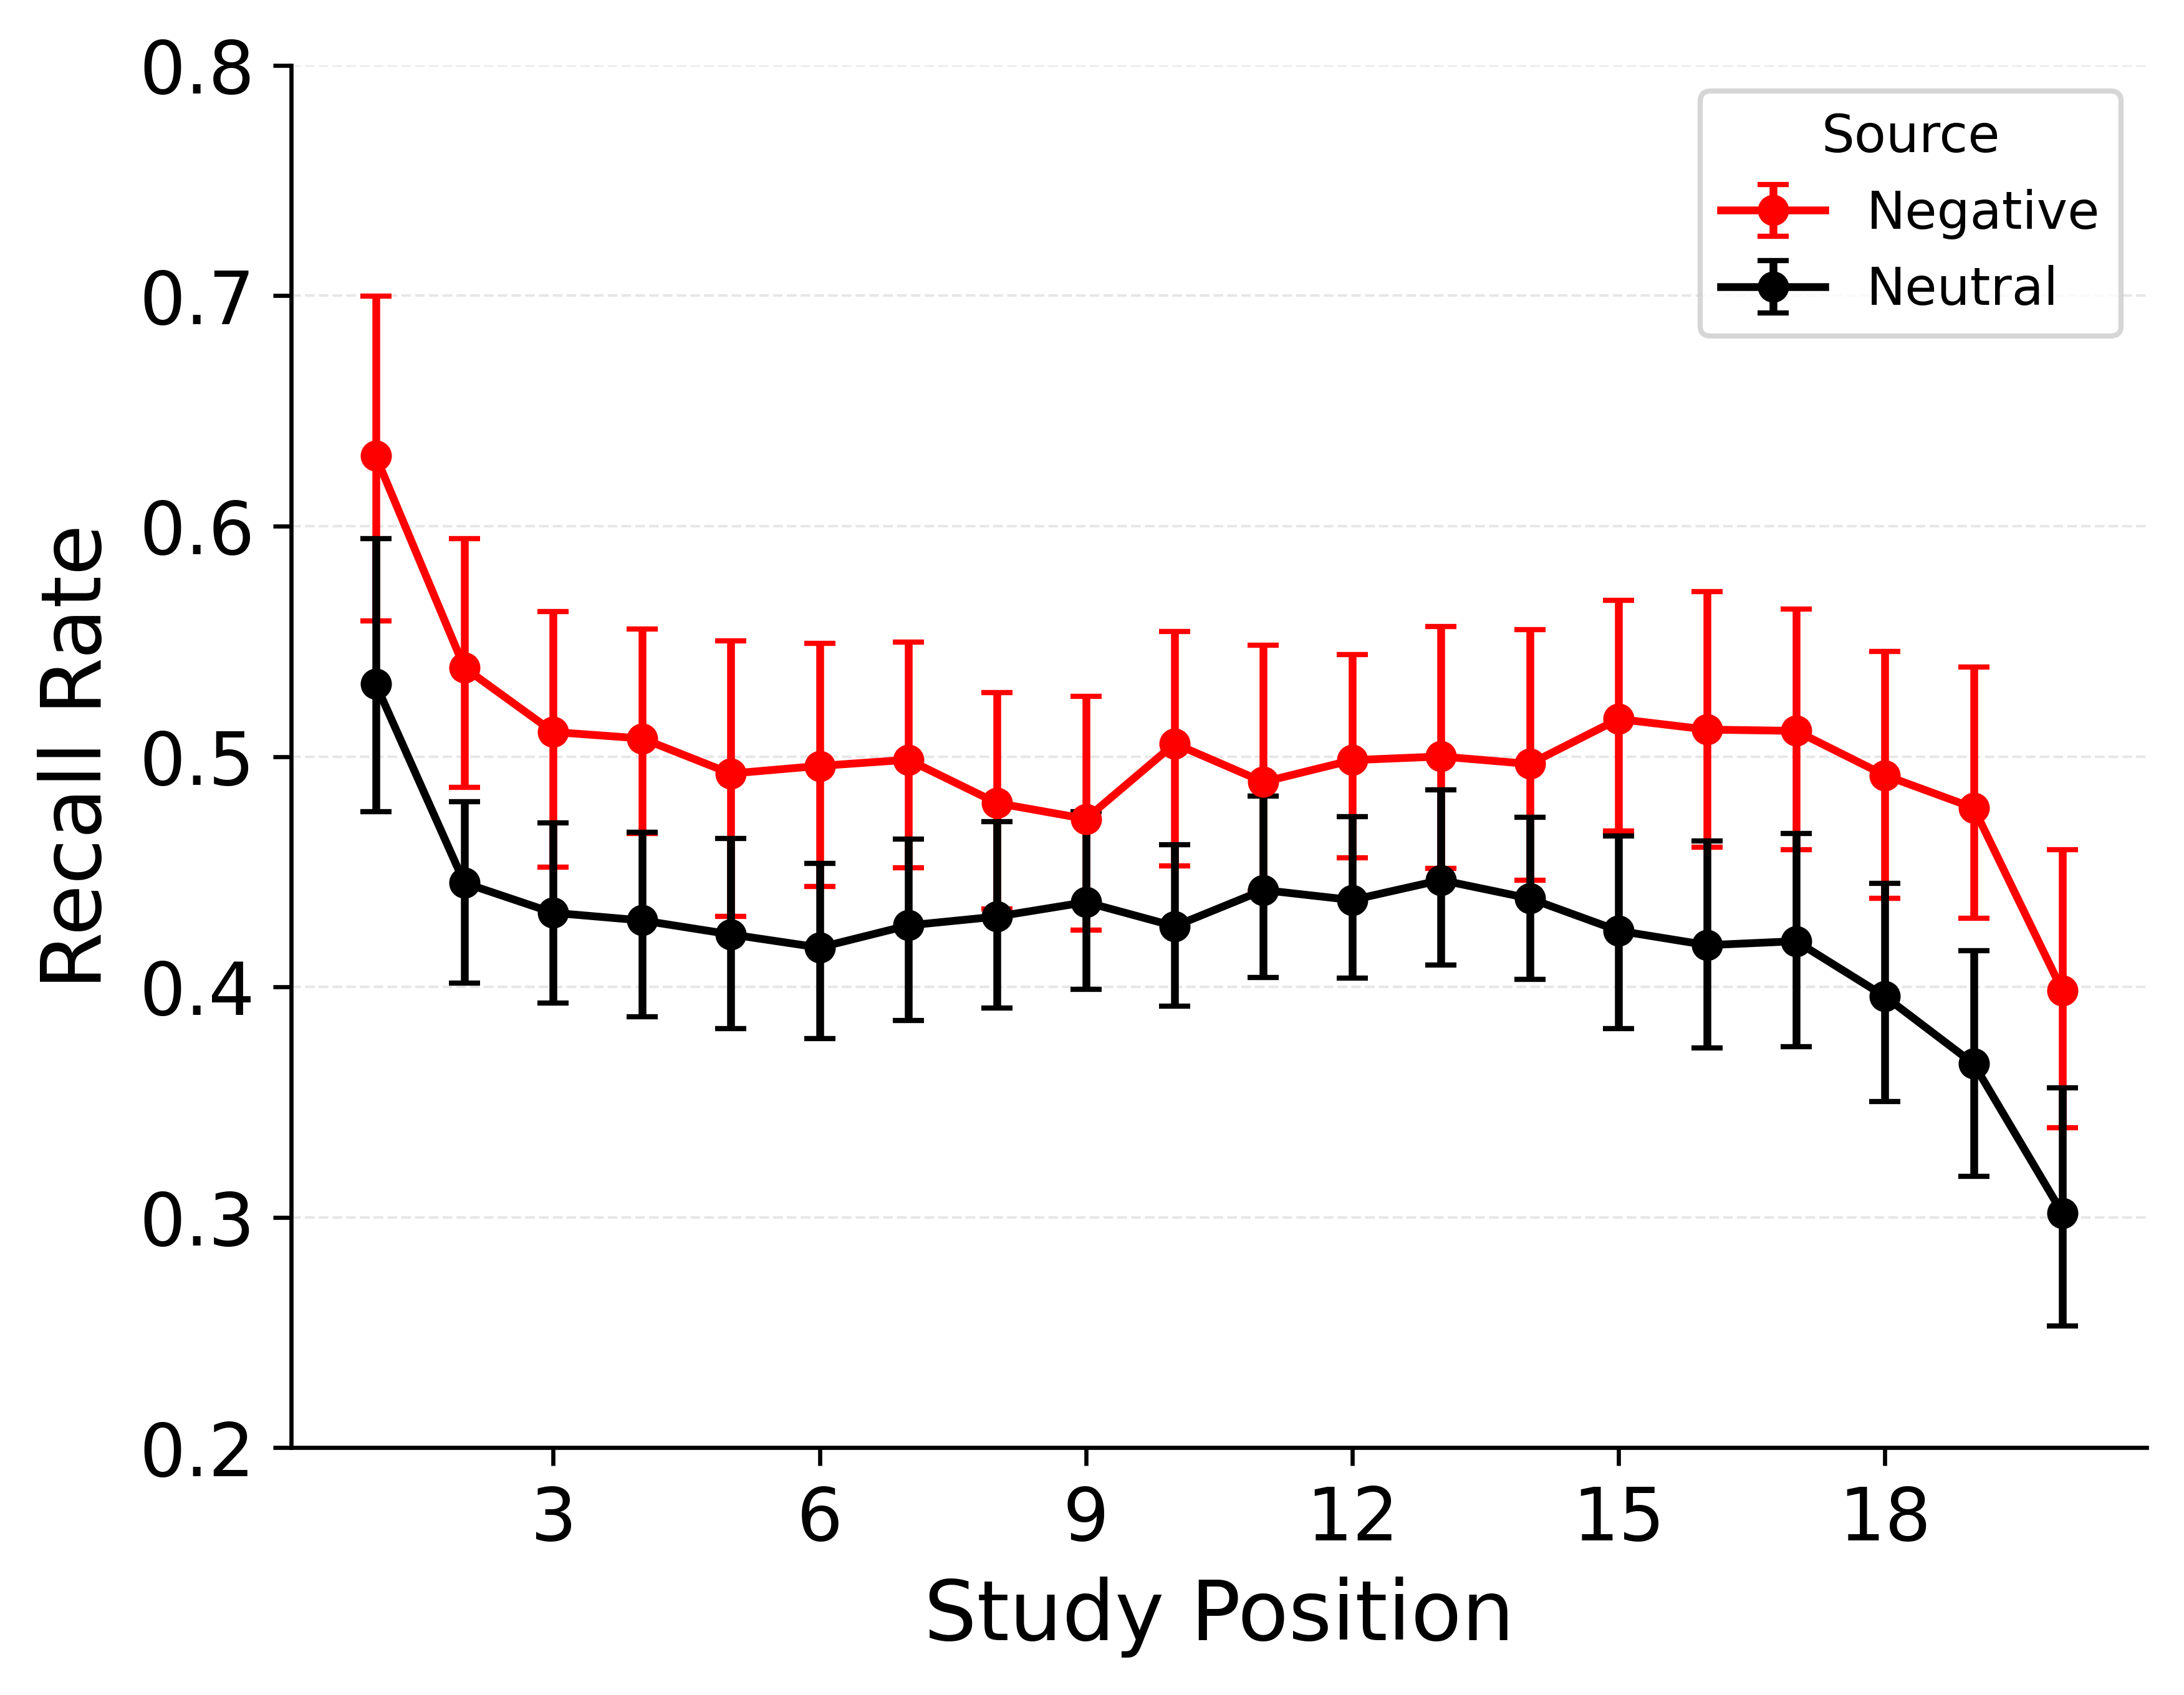

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_cat_lpp_by_recall_NEGATIVE_EARLYLPP.png)


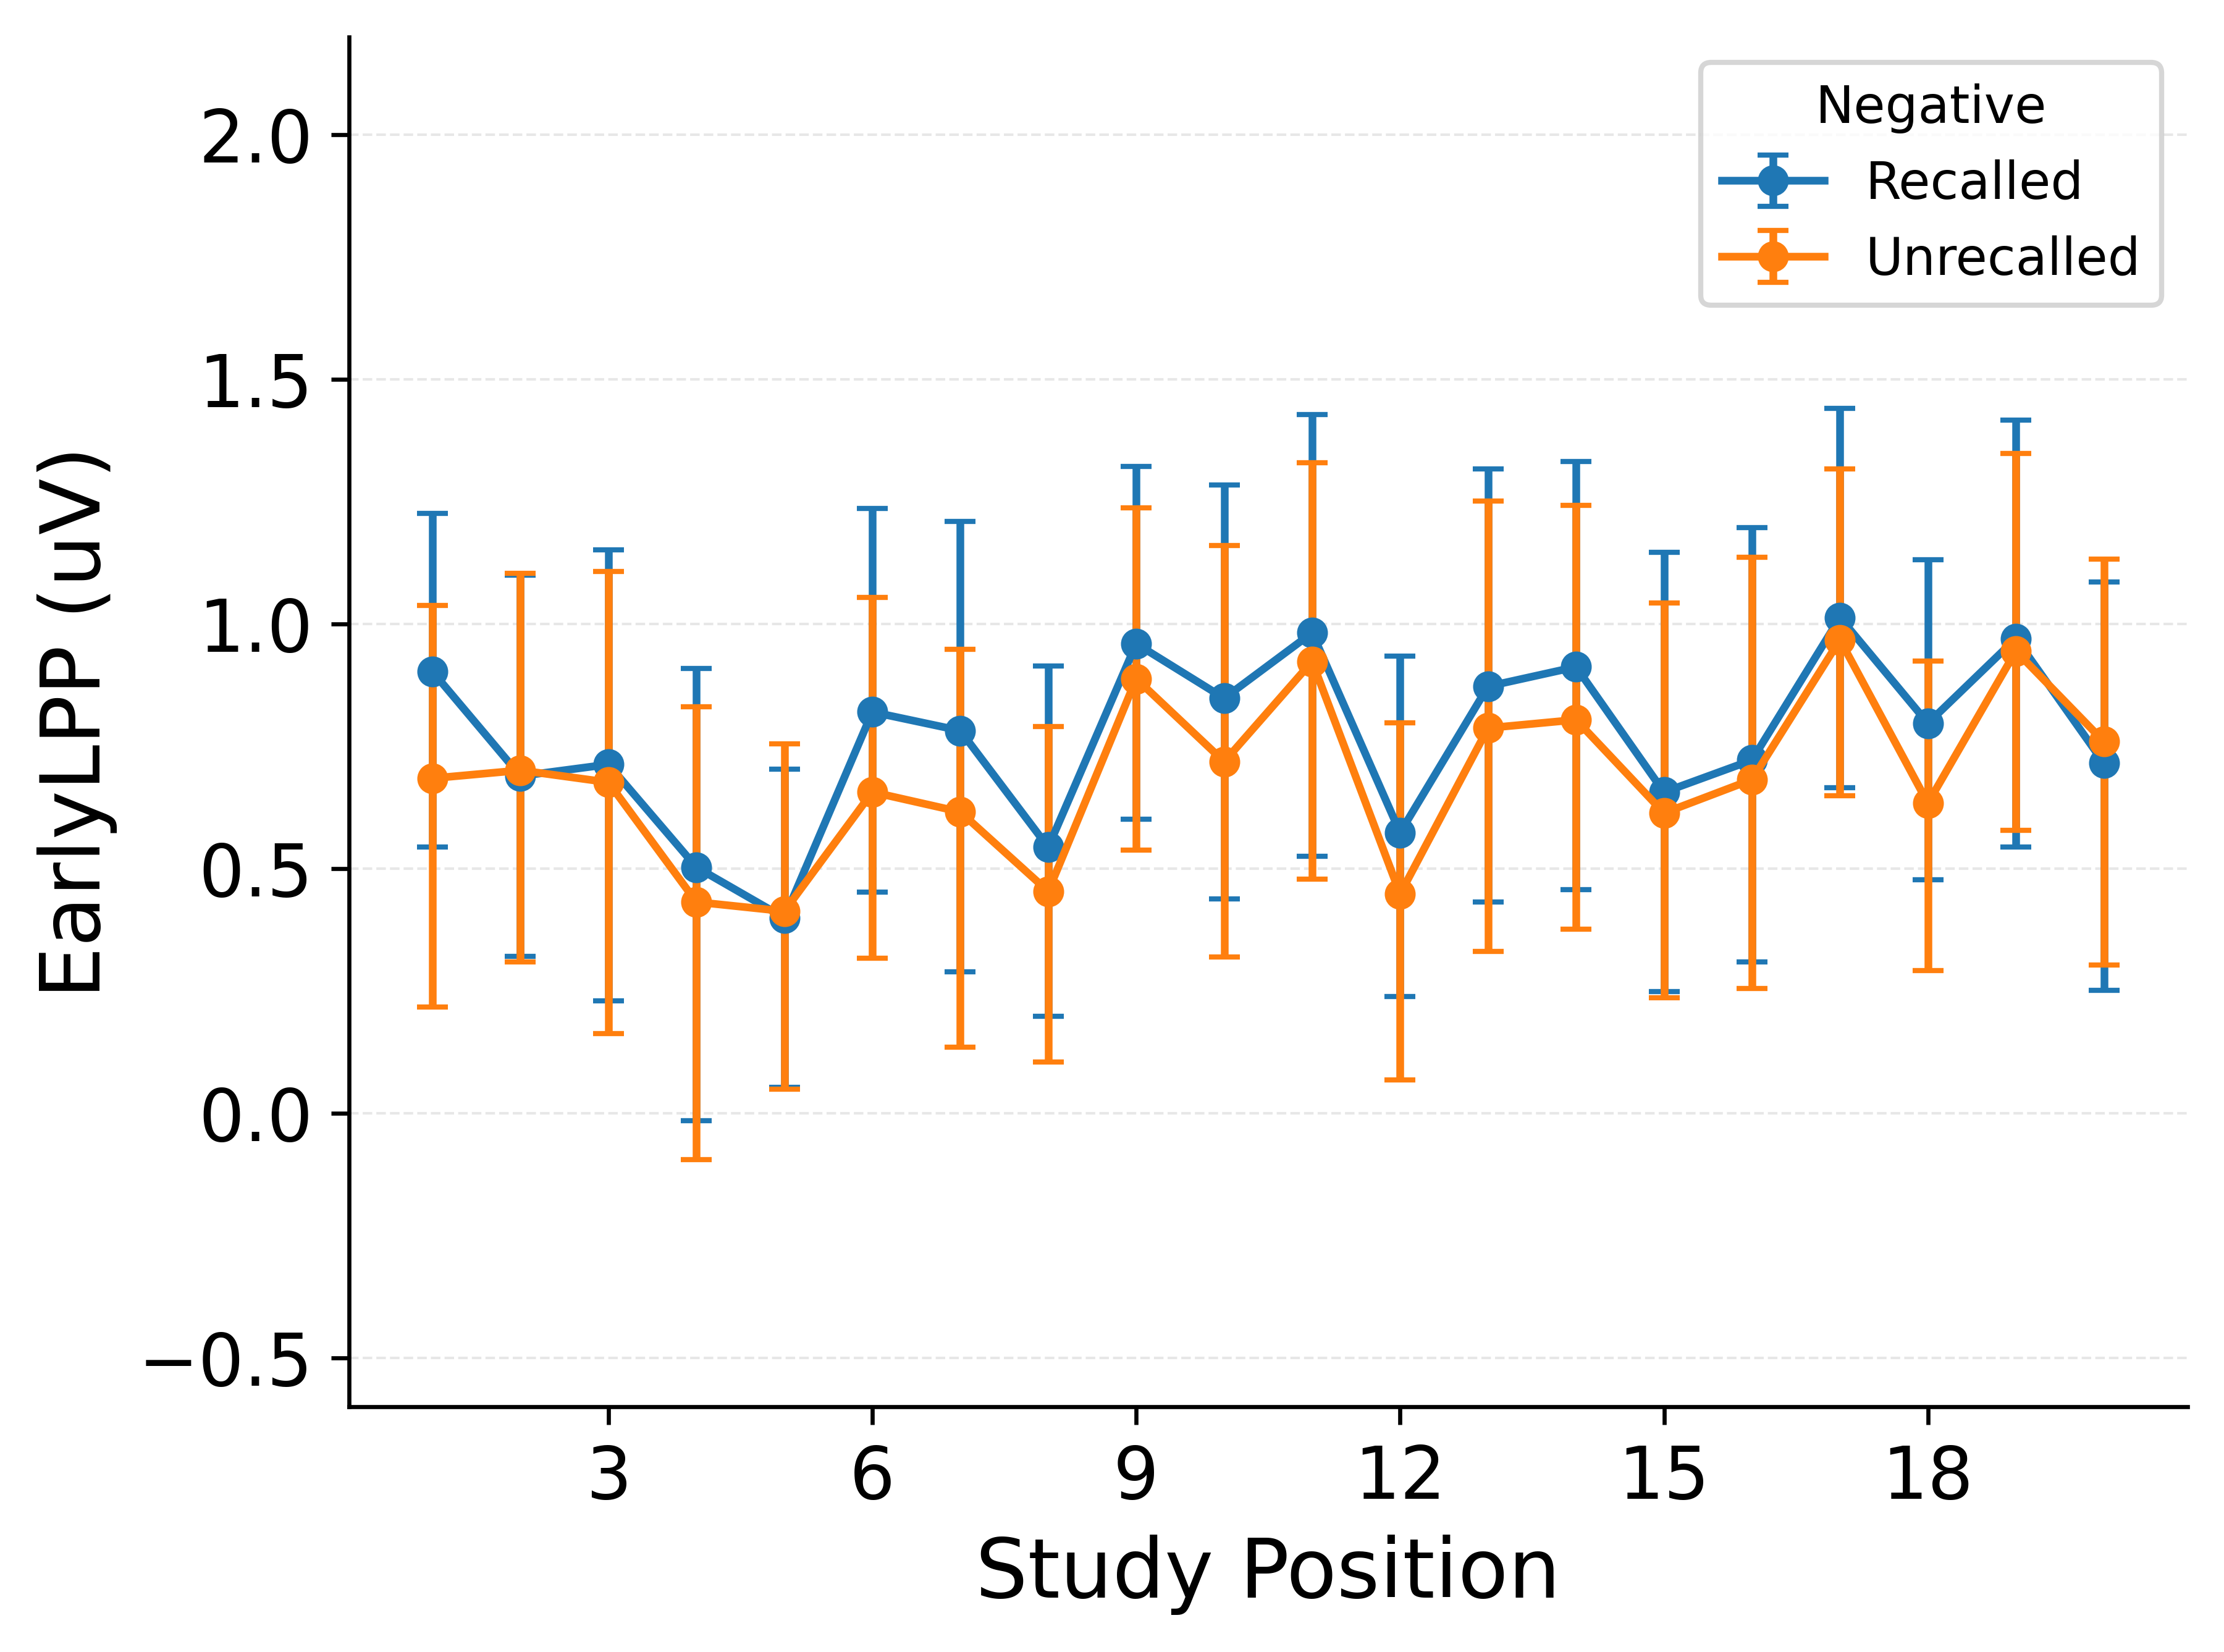

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_cat_lpp_by_recall_NEUTRAL_EARLYLPP.png)


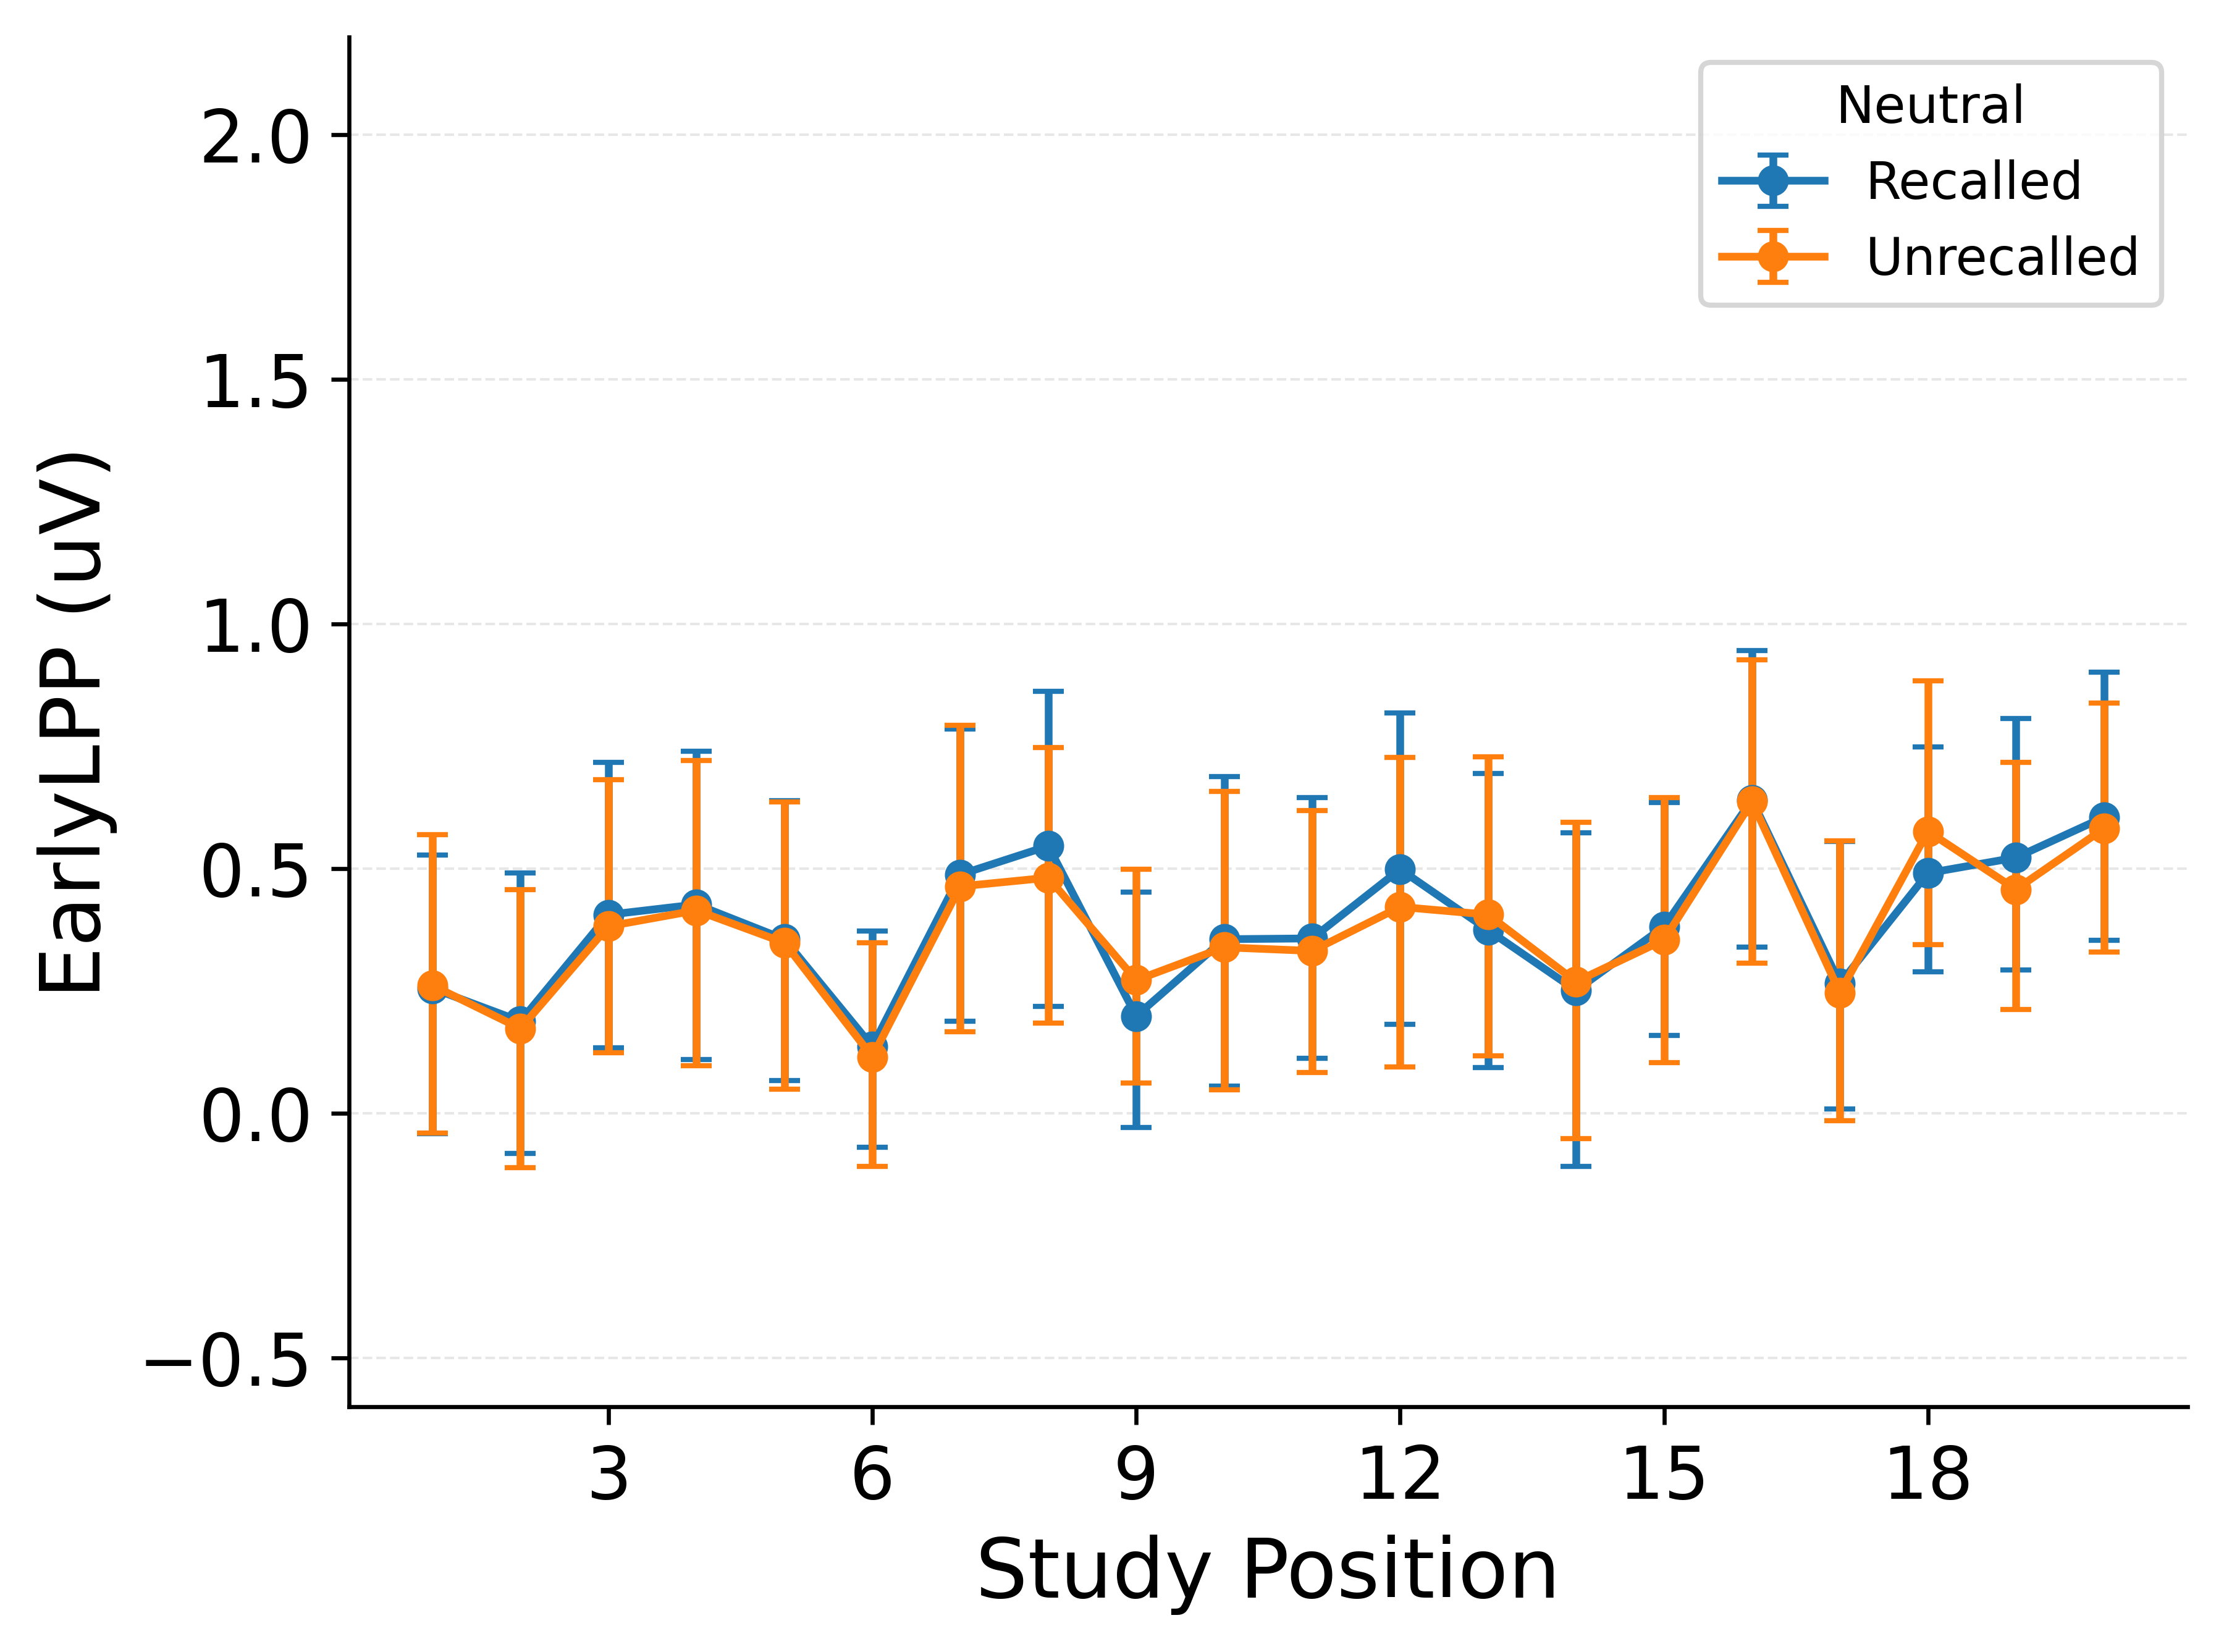

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_cat_spc_negative.png)


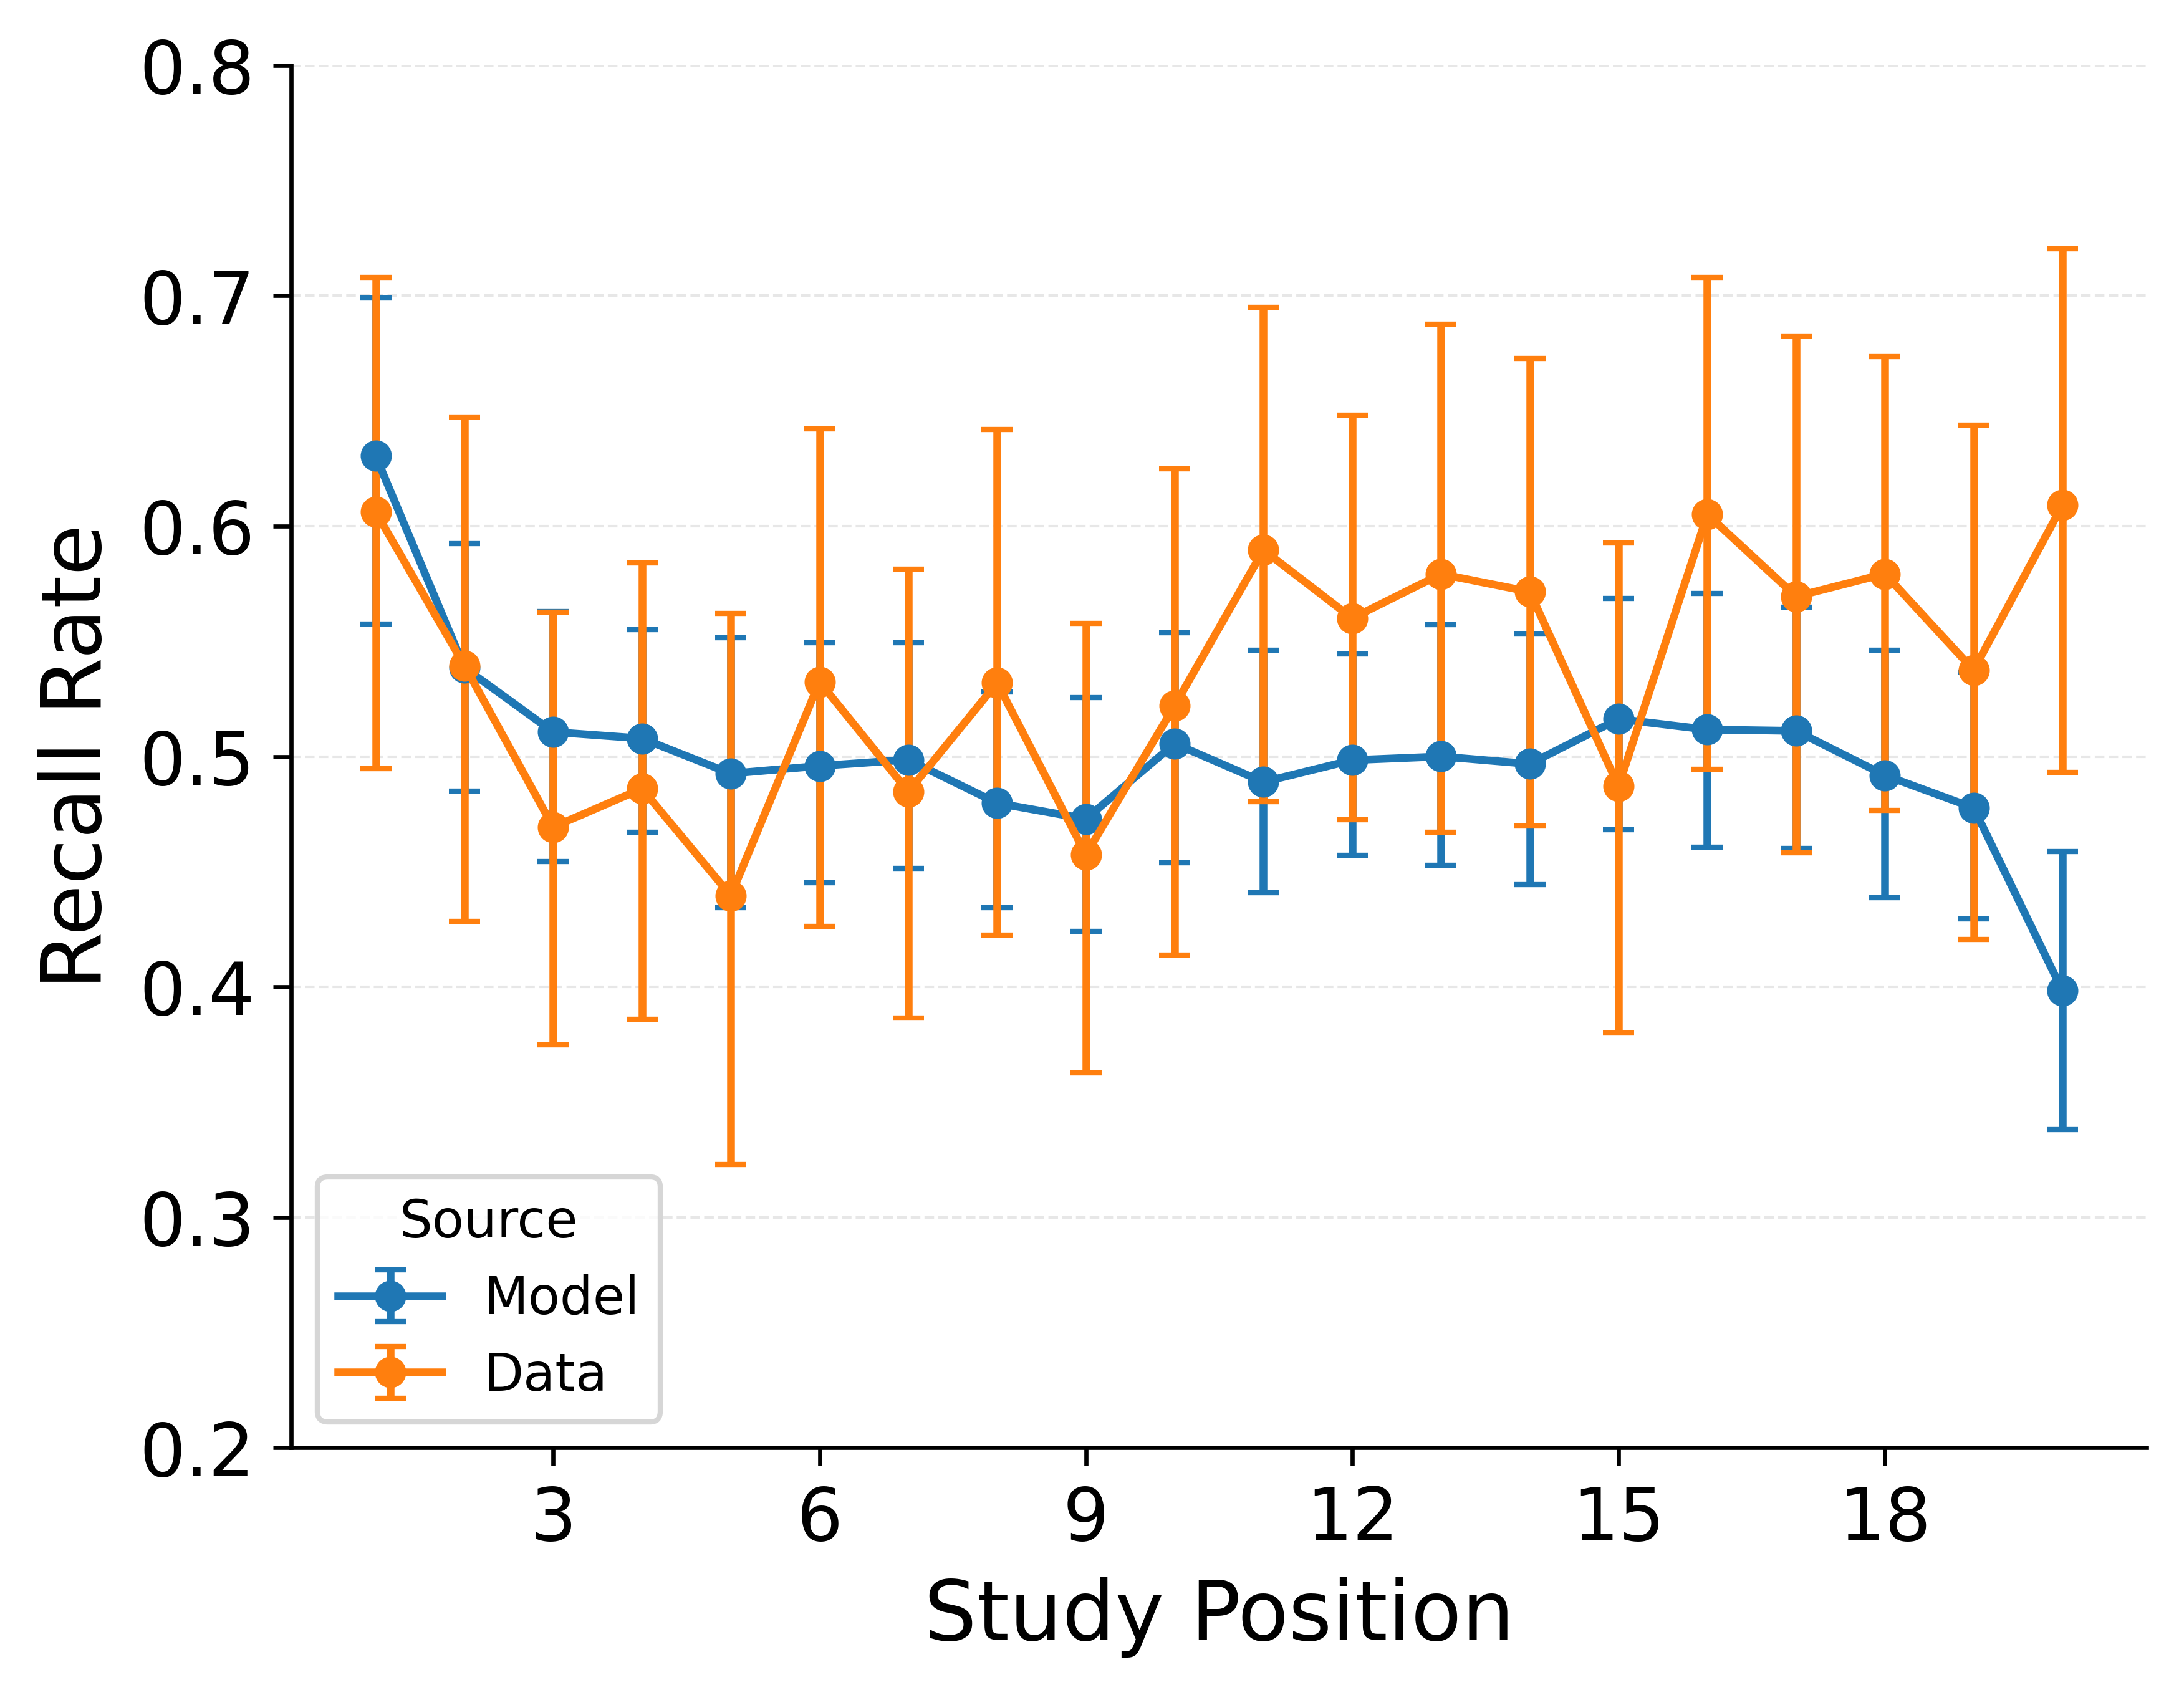

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_cat_spc_neutral.png)


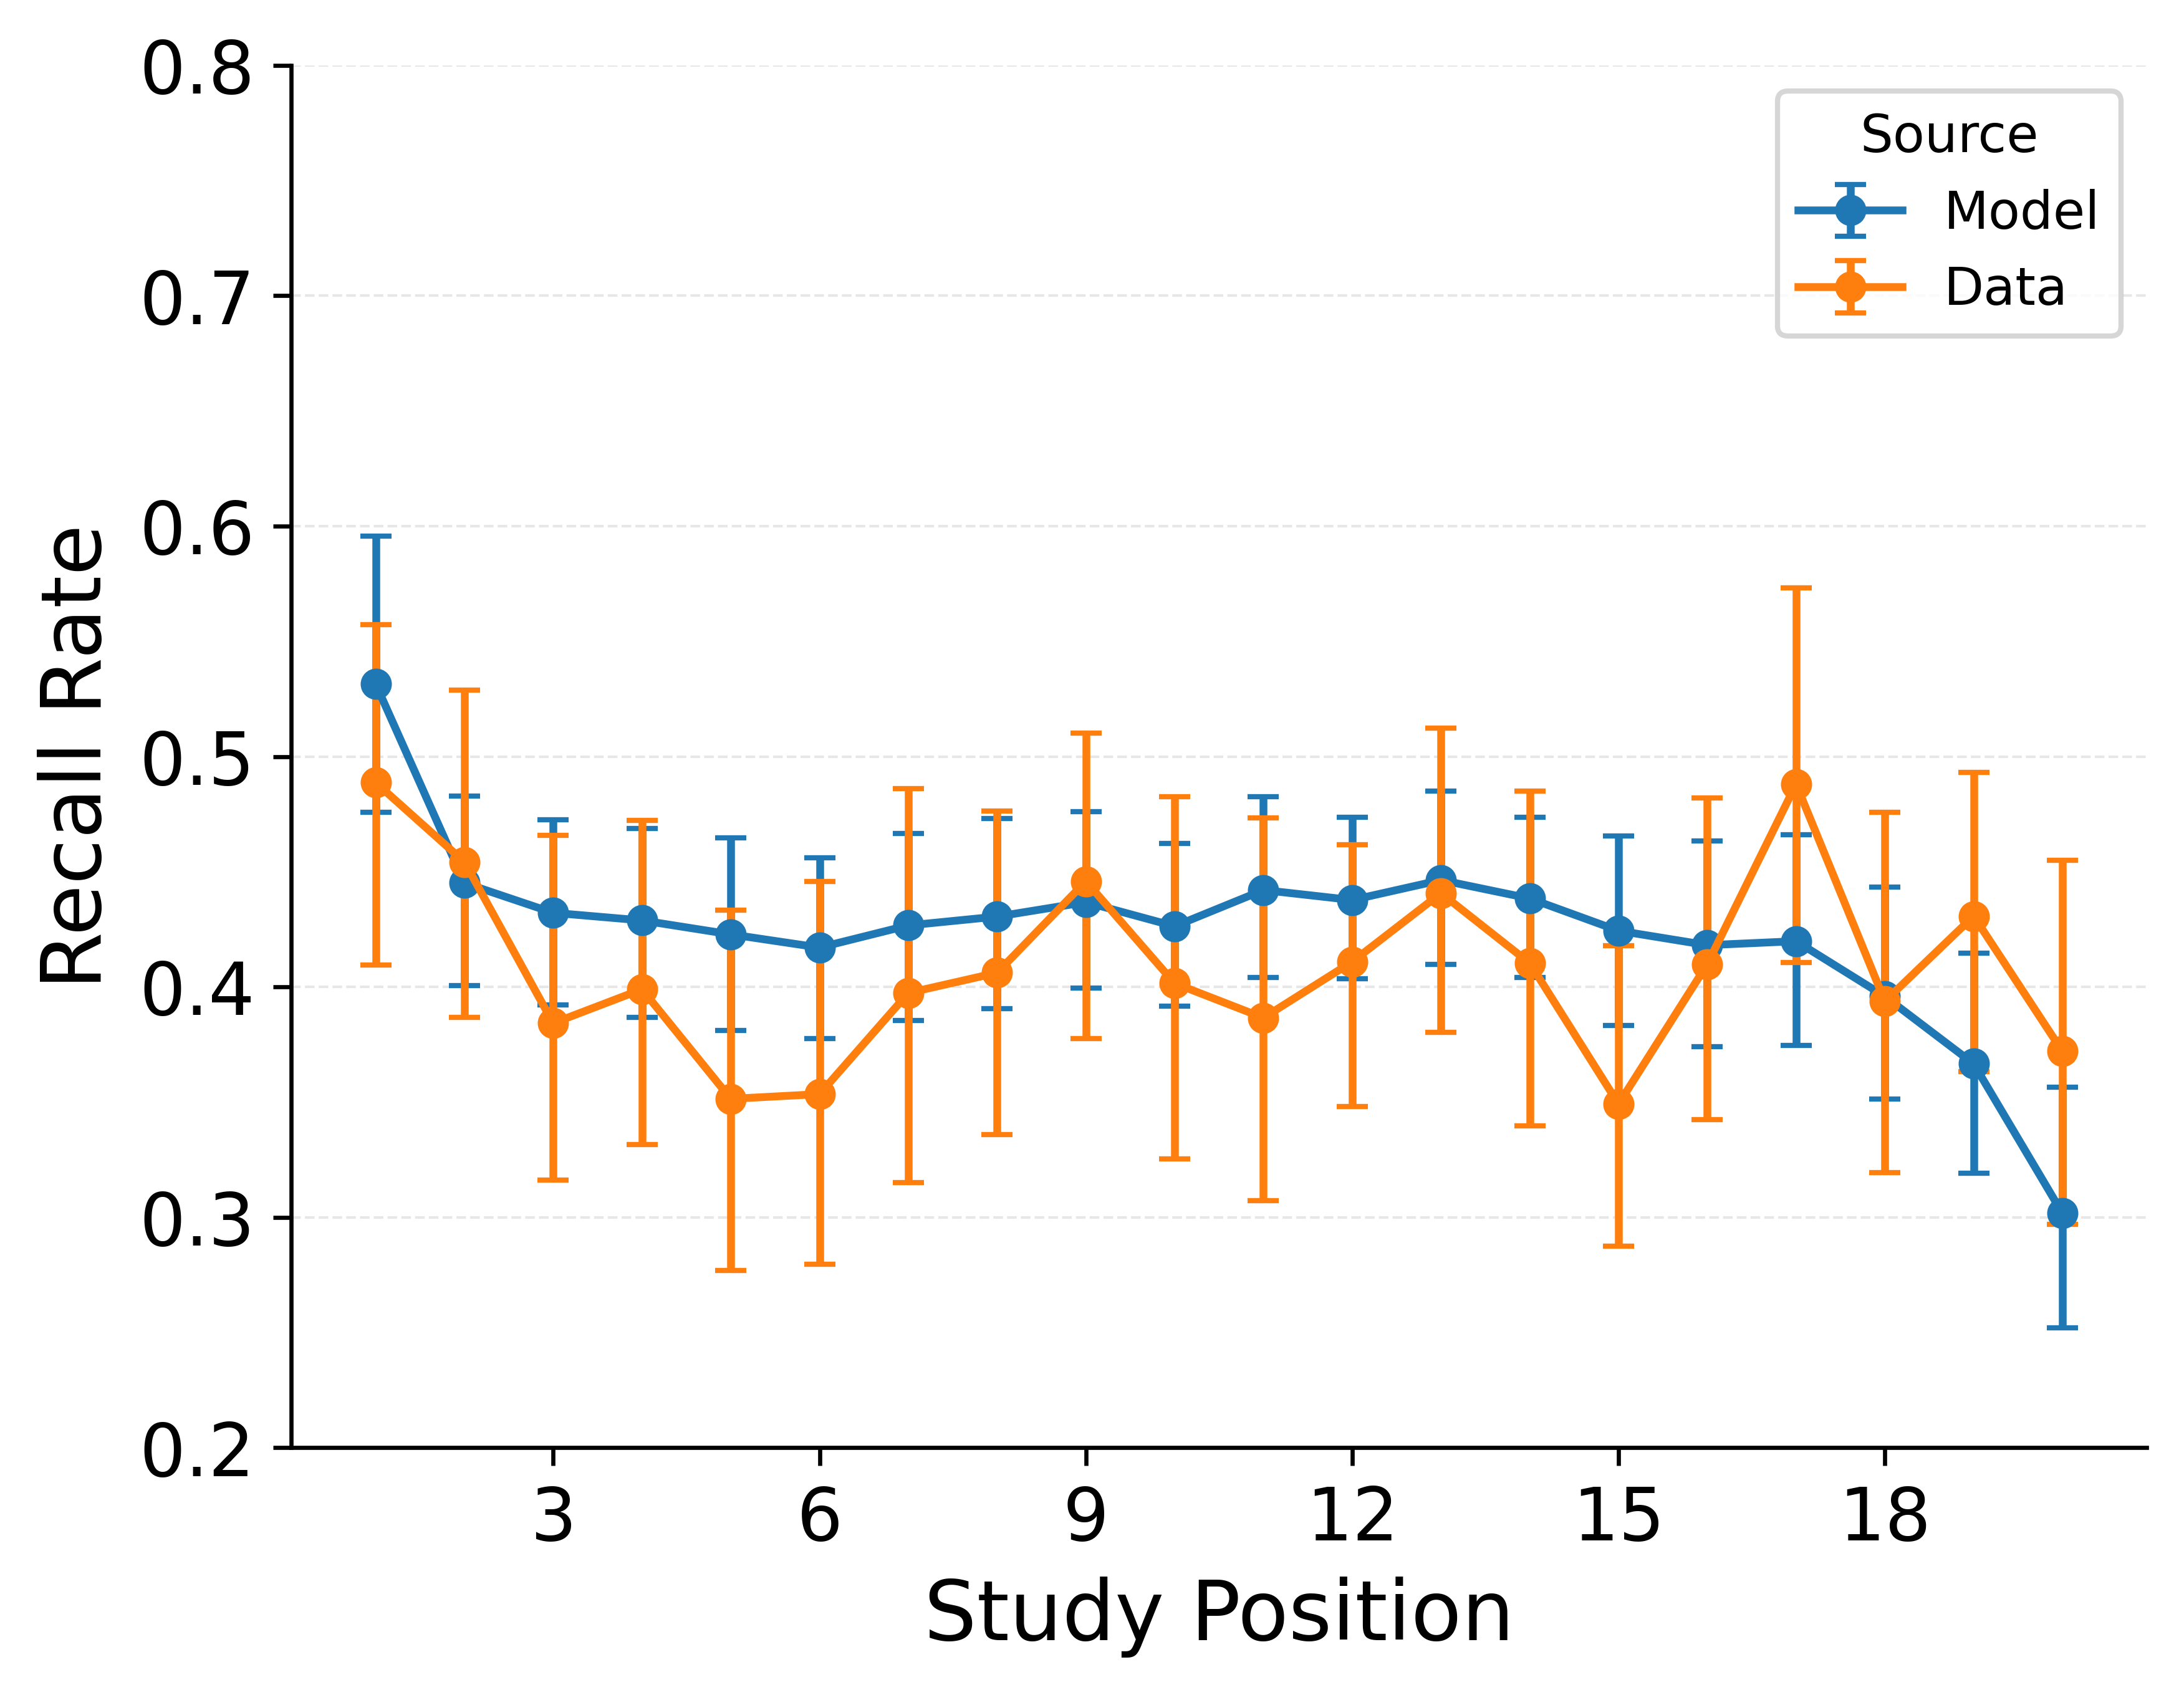

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/TalmiEEG_2EEGAttentionECMRNoStop_cat_spc_mse_fixed_term_best_of_3_spc.png)


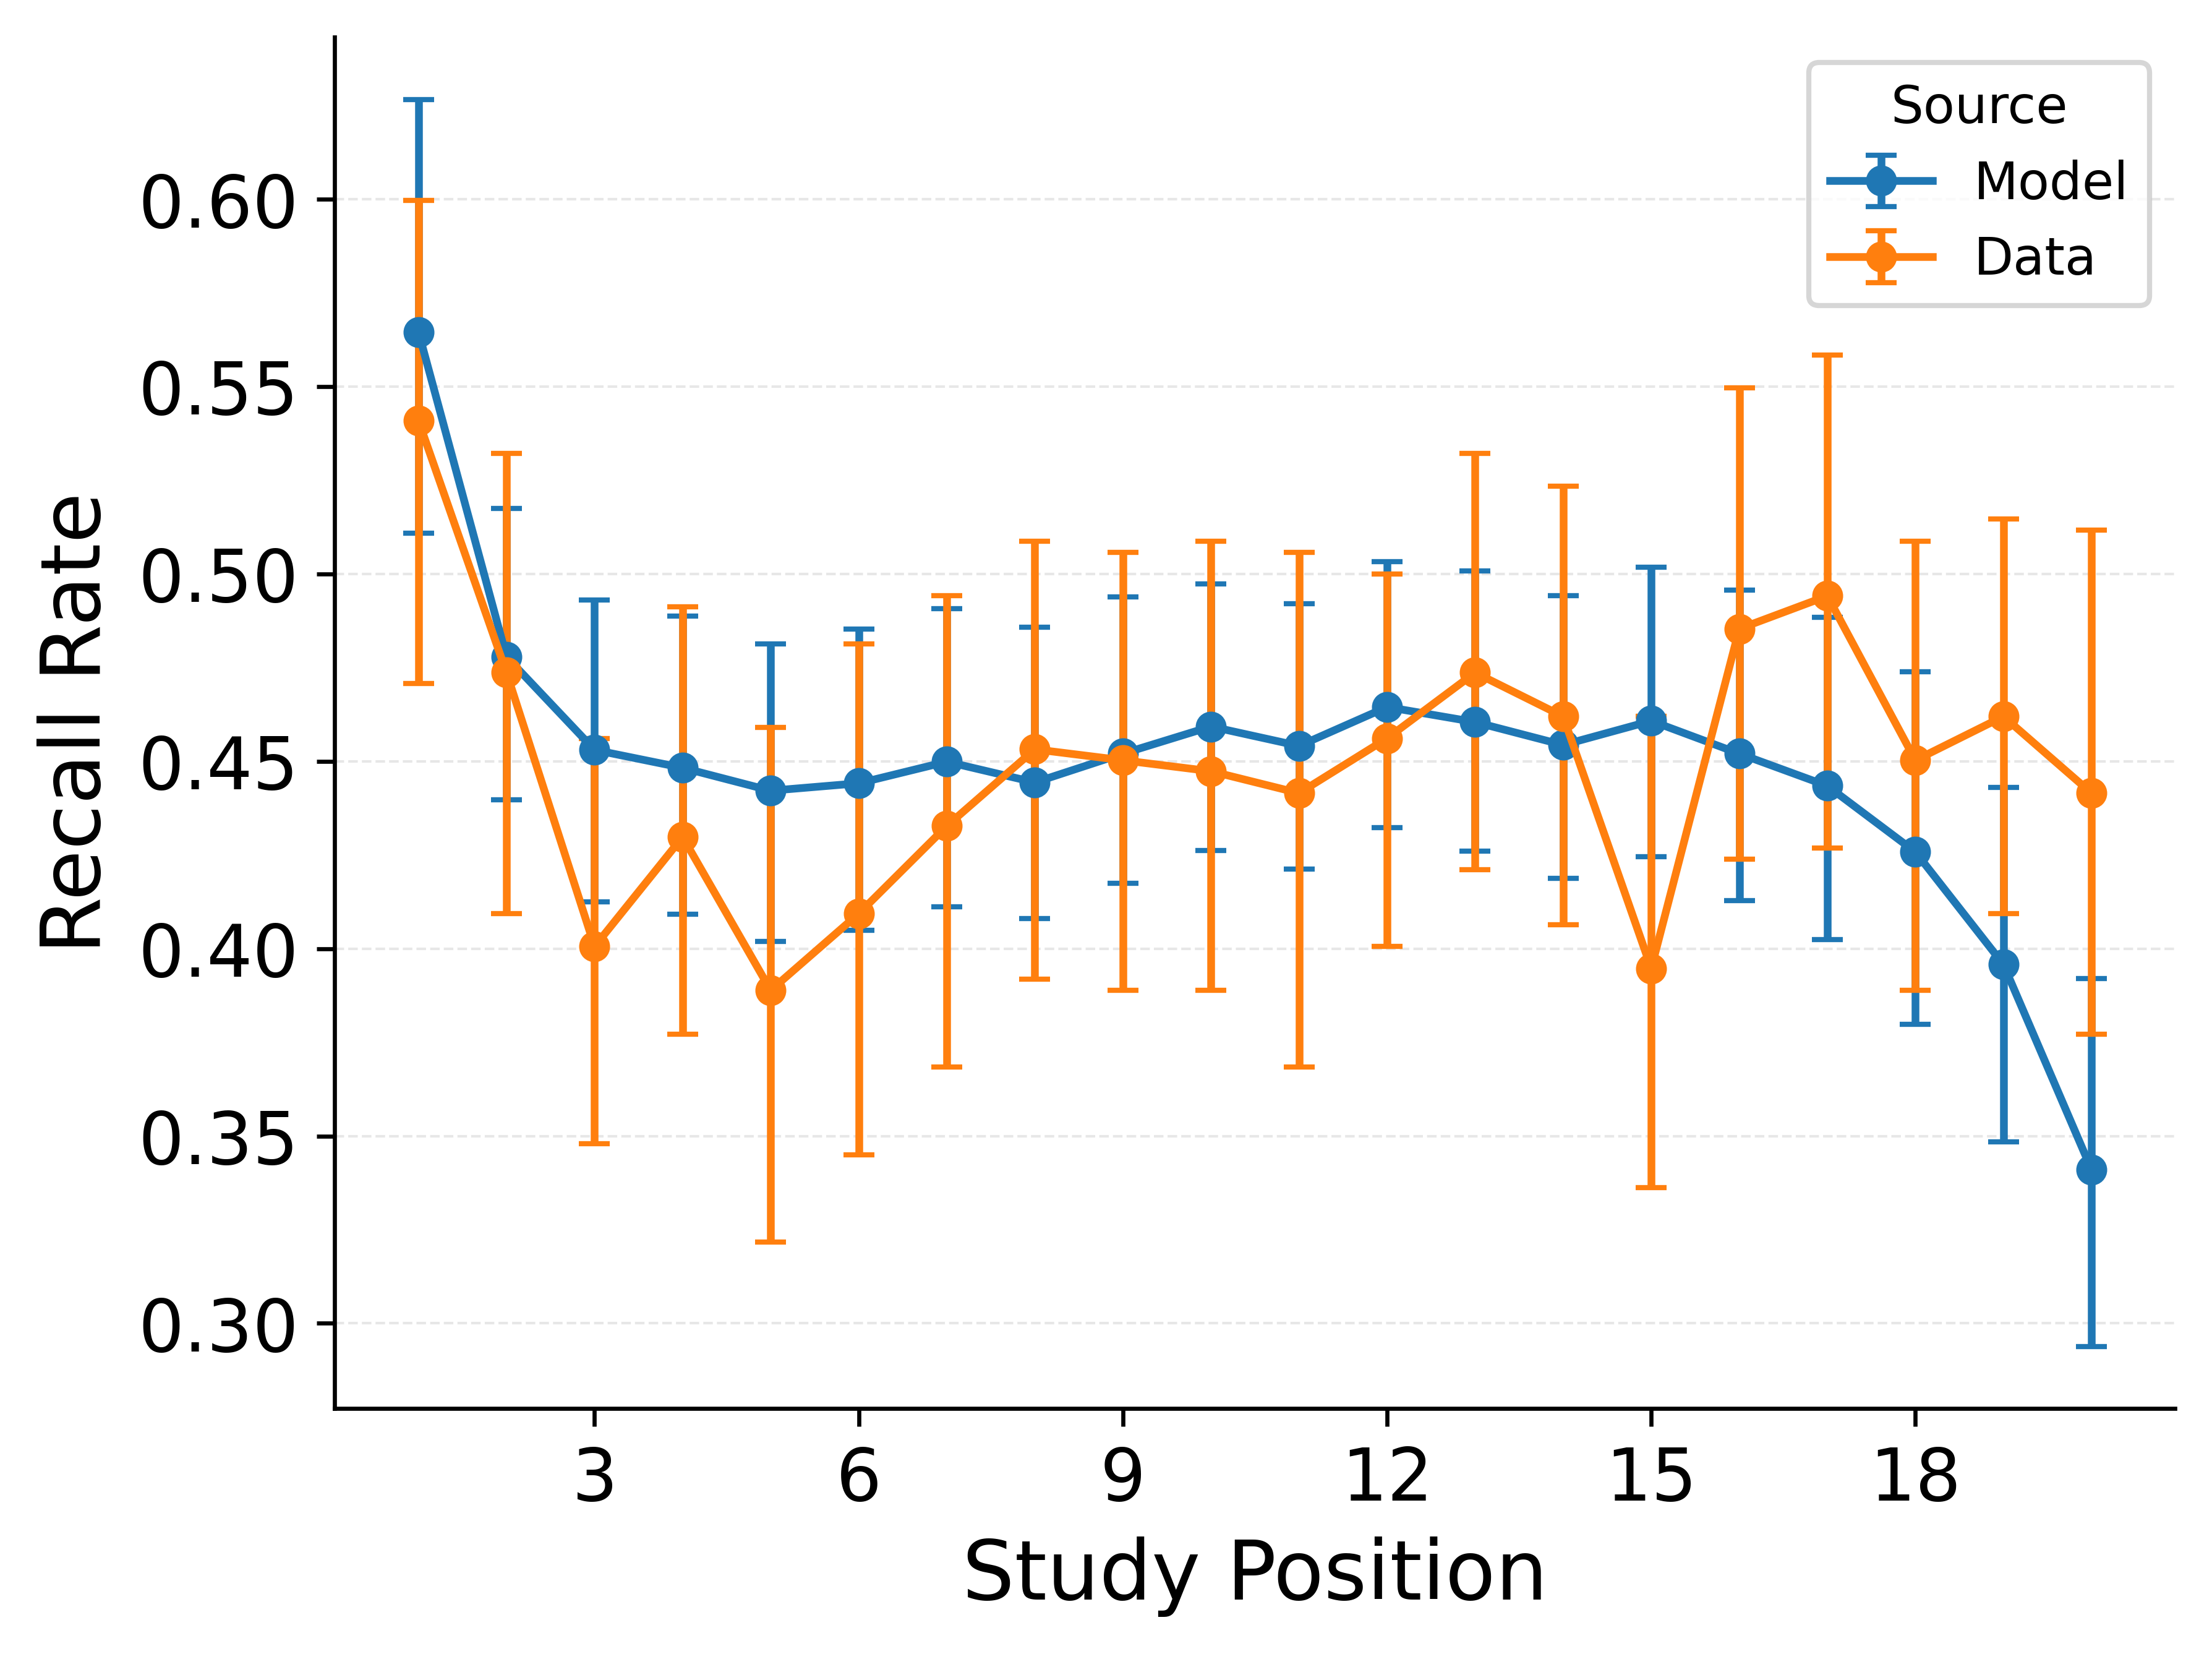

In [ ]:
for partial_params in varied_parameters:
    params = base_params.copy() | partial_params
    data_tag = params["data_tag"]
    model_name = params["model_name"]
    base_run_tag = params["base_run_tag"]
    best_of = params["best_of"]
    run_tag = f"{base_run_tag}_best_of_{best_of}"
    max_subjects = params["max_subjects"]
    if max_subjects:
        run_tag += f"_nsubs_{max_subjects}"

    output_path = f"{find_project_root()}/projects/TalmiEEG/notebooks/fitting_{data_tag}_{model_name}_{run_tag}.ipynb"
    print(output_path)

    pm.execute_notebook(
        f"{find_project_root()}/templates/fitting.ipynb",
        output_path,
        parameters=params,
        progress_bar=False,
    )

    for analysis_cfg in params["single_analysis_configs"]:
        figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis_cfg['figure_suffix']}.png"
        figure_path = os.path.join(
            f"{find_project_root()}/projects/TalmiEEG/results/figures/{figure_str}"
        )
        print(f"![]({figure_path})")
        display(Image(filename=figure_path, width=600))
        
    for analysis_cfg in params["comparison_analysis_configs"]:
        figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis_cfg['figure_suffix']}.png"
        figure_path = os.path.join(
            f"{find_project_root()}/projects/TalmiEEG/results/figures/{figure_str}"
        )
        print(f"![]({figure_path})")
        display(Image(filename=figure_path, width=600))
